In [1]:
from methods import DataGenerator, Reservoir, BayesianStateMCMC
from utils import partition_states, z_rescale_tensor,  evaluate_metrics,  calibrate 

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.io as sio

# Synthetic Data

## Pre Processing

In [2]:
# Global Params
Time_steps = 2400
tau = 20
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

In [3]:
generator = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t)
X_full, Y_full = generator.generate_data()

In [4]:
# Extract Z-Scoring Variables from Train Data
train_boundary = int(0.50 * len(X_full))

train_mean_X = np.mean(X_full[:train_boundary], axis=0)
train_std_X = np.std(X_full[:train_boundary], axis=0)
train_std_X[train_std_X == 0] = 1.0

train_mean_Y = np.mean(Y_full[:train_boundary], axis=0)
train_std_Y = np.std(Y_full[:train_boundary], axis=0)
train_std_Y[train_std_Y == 0] = 1.0

X_z = (X_full - train_mean_X) / train_std_X
Y_z = (Y_full - train_mean_Y) / train_std_Y

In [5]:
# Reservoir Generation
input_dim = X_z.shape[1]
res = Reservoir(input_dim=input_dim, reservoir_dim=500, spectral_radius=0.9, seed=42)

S_full = res.get_states(X_z)

# Global Washout Slicing & Target Alignment (Y[t] is predicted by S[t-1])
washout = 50
S_valid = S_full[washout:-1]
Y_valid = Y_z[washout+1:]

block_size = 100

# Block Partitioning (Arbitrary Size and Buffer)
S_blocks, Y_blocks = partition_states(S_valid, Y_valid, block_size, buffer_size=0)
total_blocks = len(S_blocks)

print("Maximum Block size:", np.max([block.shape[0] for block in S_blocks]))
print("Minimum Block size:", np.min([block.shape[0] for block in S_blocks]))
print("Number of Total Blocks:", total_blocks)

Maximum Block size: 100
Minimum Block size: 49
Number of Total Blocks: 24


In [6]:
# Distribute into 4 Splits (50% / 15% / 15% / 20%)
n_train = int(0.50 * total_blocks)
n_val = int(0.15 * total_blocks)
n_cal = int(0.15 * total_blocks)

total_idxs = np.arange(total_blocks, dtype=int)
train_idxs = np.random.choice(total_idxs, n_train, False)

val_choice_idxs = np.delete(total_idxs, train_idxs)
val_idxs  = np.random.choice(val_choice_idxs, n_val, False)

cal_choice_idxs = np.delete(total_idxs, np.hstack((train_idxs, val_idxs)))
cal_idxs = np.random.choice(cal_choice_idxs, n_cal, False)

test_idxs = np.delete(total_idxs, np.hstack((train_idxs, val_idxs, cal_idxs)))

In [7]:
S_train = [S_blocks[i] for i in train_idxs]
Y_train = [Y_blocks[i] for i in train_idxs]

S_val = [S_blocks[i] for i in val_idxs]
Y_val = [Y_blocks[i] for i in val_idxs]

S_cal = [S_blocks[i] for i in cal_idxs]
Y_cal = [Y_blocks[i] for i in cal_idxs]

S_test = [S_blocks[i] for i in test_idxs]
Y_test = [Y_blocks[i] for i in test_idxs]

print(f"Blocks -> Train: {len(S_train)/total_blocks:.2%} | Val: {len(S_val)/total_blocks:.2%} | Cal: {len(S_cal)/total_blocks:.2%} | Test: {len(S_test)/total_blocks:.2%}")

Blocks -> Train: 50.00% | Val: 12.50% | Cal: 12.50% | Test: 25.00%


## Training

In [8]:
# Train the Estimator
estimator = BayesianStateMCMC(
    beta_params=[0, 10.], 
    scale=10., 
    n_components=16,   # Lower components for synthetic dataset
    num_samples=1000, 
    warmup_steps=500
)

estimator.fit(S_train, Y_train)

Sample: 100%|██████████| 1500/1500 [03:32,  7.05it/s, step size=2.00e-02, acc. prob=0.944]


,beta_params,"[0, 10.0]"
,scale,10.0
,n_components,16
,num_samples,1000
,warmup_steps,500
,seed,42


## Validation

In [9]:
# Extract Predictive Distributions for Val
_ = estimator.predict(S_val)
y_pred_val_z = estimator.y_pred_samples_z_.cpu().numpy()
Y_val_stack = np.vstack(Y_val)

y_pred_val_rescaled = z_rescale_tensor(torch.tensor(y_pred_val_z), train_mean_Y, train_std_Y)
Y_val_rescaled = z_rescale_tensor(torch.tensor(Y_val_stack), train_mean_Y, train_std_Y)

# Extract distributional moments
median_prediction = torch.median(y_pred_val_rescaled, dim=0)[0]
mean_prediction = torch.mean(y_pred_val_rescaled, dim=0)
std_prediction = torch.std(y_pred_val_rescaled, dim=0)

lower_bound = torch.quantile(y_pred_val_rescaled, 0.025, dim=0)
upper_bound = torch.quantile(y_pred_val_rescaled, 0.975, dim=0)

# Projection and Visualization

median_prediction = median_prediction.numpy()
lower_bound = lower_bound.numpy().squeeze()
upper_bound= upper_bound.numpy().squeeze()

In [10]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
hor = block_size

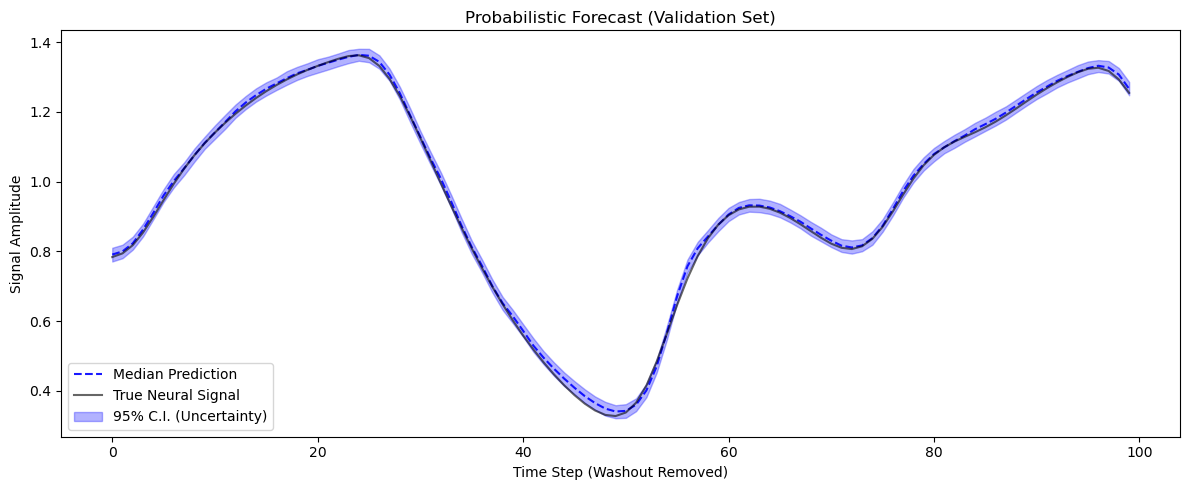

Val Empirical Coverage: 97.3333% (Target: 95%)
Val Calibration Error: 9.5799% (Target: 0%)
Val mCRPS: 0.0053
Val Width: 0.0372


In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
plt.plot(median_prediction[:hor], "b--", alpha=0.9, label="Median Prediction")
plt.plot(Y_val_rescaled[:hor], "k-", alpha=0.6, label="True Neural Signal")
plt.fill_between(
    range(hor),
    lower_bound[:hor],
    upper_bound[:hor],
    color="blue",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step (Washout Removed)")
plt.ylabel("Signal Amplitude")
plt.title(f"Probabilistic Forecast (Validation Set)")
plt.tight_layout()
plt.legend()
plt.show()

cov_val, cal_error, mcrps_val, width_val = evaluate_metrics(
    y_pred_val_rescaled, 
    Y_val_rescaled, 
    cov_prob=0.95, 
    quantiles=robust_quantiles # Note: to evaluate strictly on recalibrated quantiles, map them here.
)
print(f"Val Empirical Coverage: {cov_val.mean():.4%} (Target: 95%)")
print(f"Val Calibration Error: {cal_error.mean():.4%} (Target: 0%)")
print(f"Val mCRPS: {mcrps_val.mean().item():.4f}")
print(f"Val Width: {width_val.mean().item():.4f}")

## Calibration

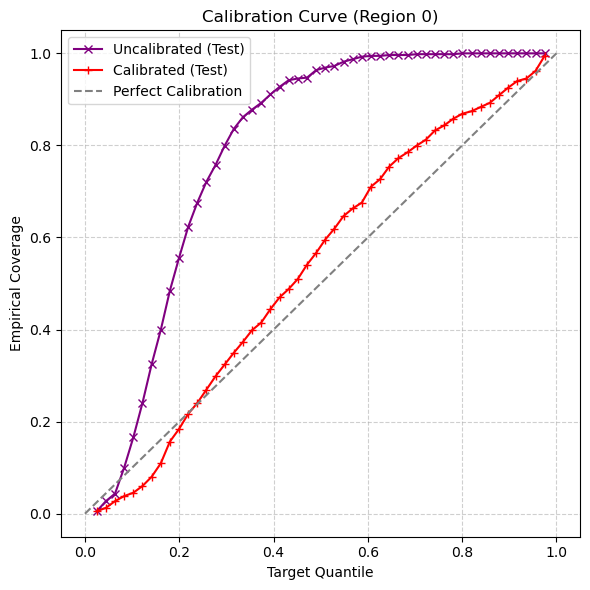

Mean MSCE (Uncalibrated Val): 12.0016%
Mean MSCE (Calibrated Val): 0.3954%


In [12]:
# Extract Predictive Distributions for Cal and Test Splits
_ = estimator.predict(S_cal)
y_pred_cal_z = estimator.y_pred_samples_z_.cpu().numpy()

_ = estimator.predict(S_test)
y_pred_test_z = estimator.y_pred_samples_z_.cpu().numpy()

# Stack Ground Truth targets for evaluation
Y_cal_stack = np.vstack(Y_cal)
Y_test_stack = np.vstack(Y_test)

# Isotonic Recalibration
robust_quantiles = np.linspace(0.025, 0.975, 50)

err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred_test_z,
    y_pred_val=y_pred_cal_z,    # Fitted on Calibration Set
    Y_test=Y_test_stack,
    Y_val=Y_cal_stack,          # Fitted on Calibration Set
    quantiles=robust_quantiles,
    plot_region=0               # Synthetic data is 1D (Region 0)
)

print(f"Mean MSCE (Uncalibrated Val): {err_uncal.mean():.4%}")
print(f"Mean MSCE (Calibrated Val): {err_cal.mean():.4%}")

## Test

In [13]:
# Final Continuous Metric Evaluation on the Calibrated Test Set
# Generate the test samples using the newly adjusted quantiles
# Note: For scale-dependent metrics mCRPS, we must apply  inverse z-score transformation here

y_pred_test_rescaled = z_rescale_tensor(torch.tensor(y_pred_test_z), train_mean_Y, train_std_Y)
Y_test_rescaled = z_rescale_tensor(torch.tensor(Y_test_stack), train_mean_Y, train_std_Y)

# Extract region-specific adjusted probability masses from the Isotonic matrix
q_lower_adj = adj_quantiles[0][0]
q_upper_adj = adj_quantiles[-1][0]

In [14]:
# Isolate region tensors
y_pred_test = y_pred_test_rescaled
Y_test = Y_test_rescaled.numpy()

hor = block_size

# Extract calibrated bounds utilizing the adjusted quantiles
median_prediction_cal = torch.quantile(y_pred_test, 0.5, dim=0).numpy()
lower_bound_cal = torch.quantile(y_pred_test, q_lower_adj, dim=0).numpy().squeeze()
upper_bound_cal = torch.quantile(y_pred_test, q_upper_adj, dim=0).numpy().squeeze()

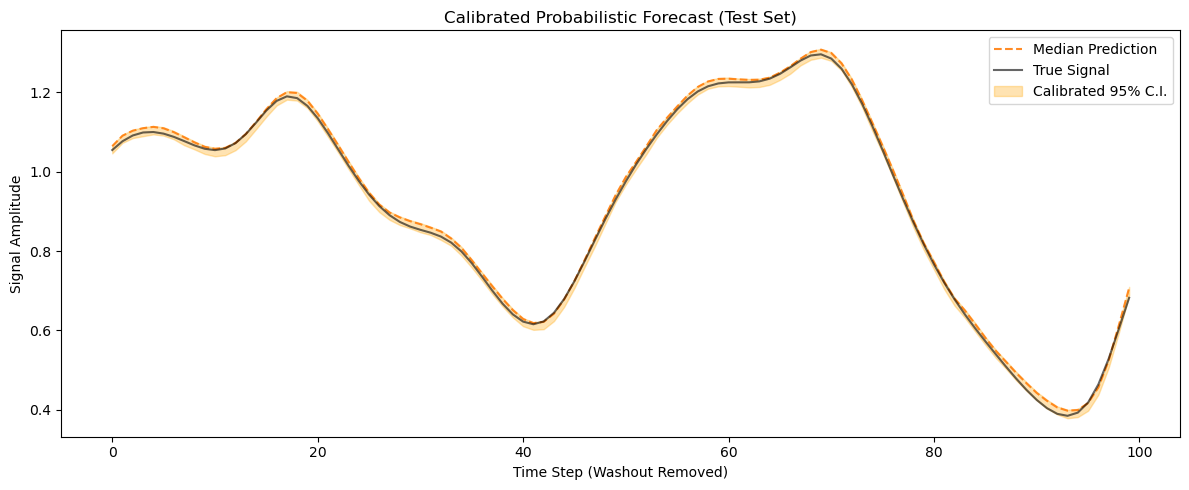

Calibrate Empirical Coverage: 99.4536% (Target: 95%)
Calibrate Calibration Error: 13.5530% (Target: 0%)
Calibrated Test mCRPS: 0.0054
Calibrated Test Width: 0.0371


In [15]:
plt.figure(figsize=(12, 5))
plt.plot(median_prediction_cal[:hor], "C1--", alpha=0.9, label="Median Prediction")
plt.plot(Y_test[:hor], "k-", alpha=0.6, label="True Signal")
plt.fill_between(
    range(hor),
    lower_bound_cal[:hor],
    upper_bound_cal[:hor],
    color="orange",
    alpha=0.3,
    label="Calibrated 95% C.I."
)

plt.xlabel("Time Step (Washout Removed)")
plt.ylabel("Signal Amplitude")
plt.title(f"Calibrated Probabilistic Forecast (Test Set)")
plt.tight_layout()
plt.legend()
plt.show()

# Recalibrated Quantile Extraction for metrics
cov_test, cal_error, mcrps_test, width_test = evaluate_metrics(
    y_pred_test_rescaled, 
    Y_test_rescaled, 
    cov_prob=0.95, 
    quantiles=adj_quantiles # Note: to evaluate on recalibrated quantiles
)

print(f"Calibrate Empirical Coverage: {cov_test.mean():.4%} (Target: 95%)")
print(f"Calibrate Calibration Error: {cal_error.mean():.4%} (Target: 0%)")
print(f"Calibrated Test mCRPS: {mcrps_test.mean().item():.4f}")
print(f"Calibrated Test Width: {width_test.mean().item():.4f}")

# Real Data

## Pre Processing

In [16]:
# Load Data
mat1 = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
mat2 = sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')

REST1 = torch.from_numpy(mat1['tseries']).float().T.cpu().numpy() # Shape: (1200, 119)
REST2 = torch.from_numpy(mat2['tseries']).float().T.cpu().numpy() # Shape: (1200, 119)

In [17]:
# Strict Z-Scoring (Compute moments ONLY on the first 600 steps of each to prevent leakage)
train_concat = np.vstack([REST1[:600], REST2[:600]])
train_mean = np.mean(train_concat, axis=0)
train_std = np.std(train_concat, axis=0)
train_std[train_std == 0] = 1.0

REST1_z = (REST1 - train_mean) / train_std
REST2_z = (REST2 - train_mean) / train_std

In [18]:
# Continuous Reservoir Generation (No washout waste inside blocks)
input_dim = REST1.shape[1]
target_dim = np.copy(input_dim)

res = Reservoir(input_dim=input_dim, reservoir_dim=500, spectral_radius=0.9, seed=42)

S1 = res.get_states(REST1_z)
S2 = res.get_states(REST2_z)

In [19]:
# Global Washout Slicing (Only the first 50 steps)
# Predict next step: Y[t] corresponds to S[t-1]
washout = 50
S1_valid, Y1_valid = S1[washout:-1], REST1_z[washout+1:]
S2_valid, Y2_valid = S2[washout:-1], REST2_z[washout+1:]

In [20]:
block_size = 100

# Block Partitioning (Arbitrary Size and Buffer)
S1_blocks, Y1_blocks = partition_states(S1_valid, Y1_valid, block_size)
S2_blocks, Y2_blocks = partition_states(S2_valid, Y2_valid, block_size)

total_blocks = len(S2_blocks)

print("Maximum Block size:", np.max([block.shape[0] for block in S1_blocks]))
print("Minimum Block size:", np.min([block.shape[0] for block in S1_blocks]))
print("Number of Total Blocks per Dayaset:", total_blocks)

Maximum Block size: 100
Minimum Block size: 49
Number of Total Blocks per Dayaset: 12


In [21]:
# Distribute into 4 Splits (50% / 15% / 15% / 20%)
n_train = int(0.50 * total_blocks)
n_val = int(0.15 * total_blocks)
n_cal = int(0.15 * total_blocks)

total_idxs = np.arange(total_blocks, dtype=int)
train_idxs = np.random.choice(total_idxs, n_train, False)

val_choice_idxs = np.delete(total_idxs, train_idxs)
val_idxs  = np.random.choice(val_choice_idxs, n_val, False)

cal_choice_idxs = np.delete(total_idxs, np.hstack((train_idxs, val_idxs)))
cal_idxs = np.random.choice(cal_choice_idxs, n_cal, False)

test_idxs = np.delete(total_idxs, np.hstack((train_idxs, val_idxs, cal_idxs)))
S_train = [S1_blocks[i] for i in train_idxs] + [S2_blocks[i] for i in train_idxs]
Y_train = [Y1_blocks[i] for i in train_idxs] + [Y2_blocks[i] for i in train_idxs]

S_val = [S1_blocks[i] for i in val_idxs] + [S2_blocks[i] for i in val_idxs]
Y_val = [Y1_blocks[i] for i in val_idxs] + [Y2_blocks[i] for i in val_idxs]

S_cal = [S1_blocks[i] for i in cal_idxs] + [S2_blocks[i] for i in cal_idxs]
Y_cal = [Y1_blocks[i] for i in cal_idxs] + [Y2_blocks[i] for i in cal_idxs]

S_test = [S1_blocks[i] for i in test_idxs] + [S2_blocks[i] for i in test_idxs]
Y_test = [Y1_blocks[i] for i in test_idxs] + [Y2_blocks[i] for i in test_idxs]

print(f"Blocks -> Train: {len(S_train)/(2*total_blocks):.2%} | Val: {len(S_val)/(2*total_blocks):.2%} | Cal: {len(S_cal)/(2*total_blocks):.2%} | Test: {len(S_test)/(2*total_blocks):.2%}")

Blocks -> Train: 50.00% | Val: 8.33% | Cal: 8.33% | Test: 33.33%


In [22]:
robust_quantiles = np.linspace(0.025, 0.975, 50)

## Training

In [23]:
# Train the Estimator
estimator = BayesianStateMCMC(
    beta_params=[0, 10.], 
    scale=10., 
    n_components=64, 
    num_samples=2000, 
    warmup_steps=500
)
estimator.fit(S_train, Y_train)

Sample: 100%|██████████| 2500/2500 [14:04,  2.96it/s, step size=5.84e-02, acc. prob=0.797]


,beta_params,"[0, 10.0]"
,scale,10.0
,n_components,64
,num_samples,2000
,warmup_steps,500
,seed,42


## Validation

In [24]:
# Extract Predictive Distributions for Val
_ = estimator.predict(S_val)
y_pred_val_z = estimator.y_pred_samples_z_.cpu().numpy()

In [25]:
Y_val_stack = np.vstack(Y_val)

y_pred_val_rescaled = z_rescale_tensor(torch.tensor(y_pred_val_z), train_mean, train_std)
Y_val_rescaled = z_rescale_tensor(torch.tensor(Y_val_stack), train_mean, train_std)

In [26]:
# Projection and Visualization
# np.random.seed(1234)
region_idx = np.random.choice(target_dim)

In [27]:
# Extract distributional moments
median_prediction = torch.median(y_pred_val_rescaled, dim=0)[0]
mean_prediction = torch.mean(y_pred_val_rescaled, dim=0)
std_prediction = torch.std(y_pred_val_rescaled, dim=0)

lower_bound = torch.quantile(y_pred_val_rescaled, 0.025, dim=0)
upper_bound = torch.quantile(y_pred_val_rescaled, 0.975, dim=0)

median_prediction_reg = median_prediction[:, region_idx].numpy()
lower_bound_reg = lower_bound[:, region_idx].numpy()
upper_bound_reg = upper_bound[:, region_idx].numpy()
Y_val_reg = Y_val_rescaled[:, region_idx]

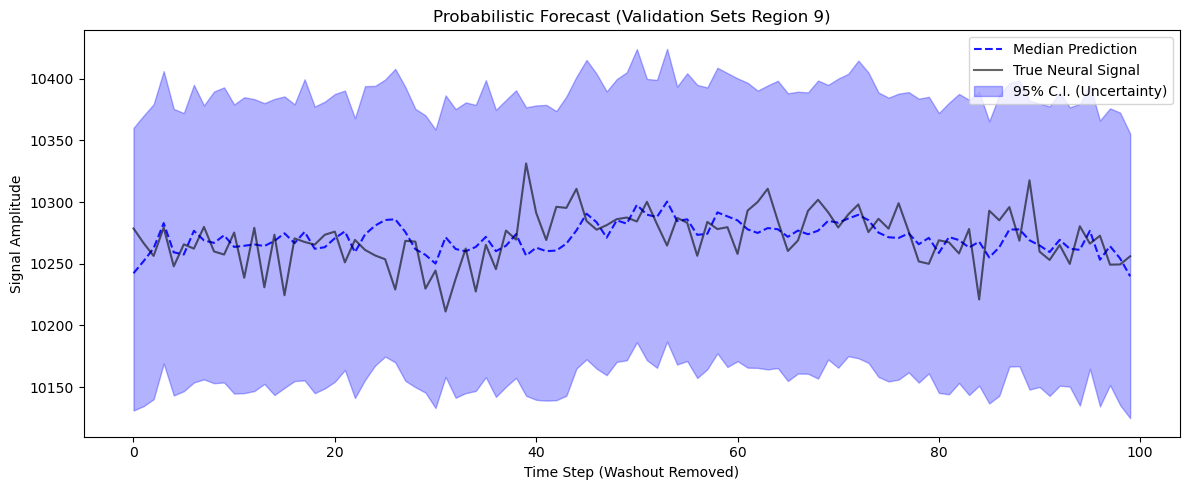

In [28]:
hor = block_size

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
plt.plot(median_prediction_reg[:hor], "b--", alpha=0.9, label="Median Prediction")
plt.plot(Y_val_reg[:hor], "k-", alpha=0.6, label="True Neural Signal")
plt.fill_between(
    range(hor),
    lower_bound_reg[:hor],
    upper_bound_reg[:hor],
    color="blue",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step (Washout Removed)")
plt.ylabel("Signal Amplitude")
plt.title(f"Probabilistic Forecast (Validation Sets Region {region_idx})")
plt.tight_layout()
plt.legend()
plt.show()

In [29]:
cov_val, cal_error, mcrps_val, width_val = evaluate_metrics(
    y_pred_val_rescaled, 
    Y_val_rescaled, 
    cov_prob=0.95, 
    quantiles=robust_quantiles # Note: to evaluate strictly on recalibrated quantiles, map them here.
)
print(f"Val Empirical Coverage: {cov_val.mean():.4%} (Target: 95%)")
print(f"Val Calibration Error: {cal_error.mean():.4%} (Target: 0%)")
print(f"Val mCRPS: {mcrps_val.mean().item():.4f}")
print(f"Val Width: {width_val.mean().item():.4f}")

Val Empirical Coverage: 93.1681% (Target: 95%)
Val Calibration Error: 2.2833% (Target: 0%)
Val mCRPS: 23.4118
Val Width: 270.8763


## Calibration

In [30]:
# Extract Predictive Distributions for Cal and Test
_ = estimator.predict(S_cal)
y_pred_cal_z = estimator.y_pred_samples_z_.cpu().numpy()

_ = estimator.predict(S_test)
y_pred_test_z = estimator.y_pred_samples_z_.cpu().numpy()

In [31]:
# Stack Ground Truth targets for evaluation
Y_cal_stack = np.vstack(Y_cal)
Y_test_stack = np.vstack(Y_test)

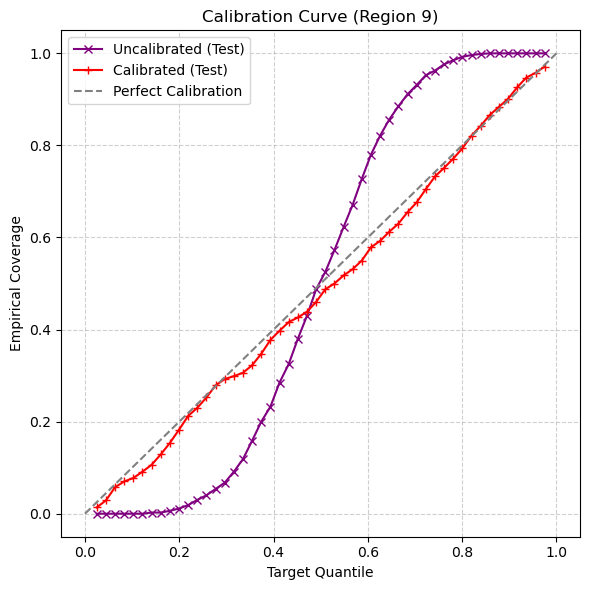

Mean MSCE (Uncalibrated Test): 2.2550%
Mean MSCE (Calibrated Test): 0.2514%


In [32]:
# Recalibration via Isotonic Regression
# We pass the Cal predictions/targets as the mapping reference ('val' in the utils function)
# The function fits the Isotonic curve on 'Cal' and applies the transformation to 'Test'

err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred_test_z,
    y_pred_val=y_pred_cal_z,    # CALIBRATION SET
    Y_test=Y_test_stack,
    Y_val=Y_cal_stack,          # CALIBRATION SET
    quantiles=robust_quantiles,
    plot_region=region_idx              # Visualize calibration curve for Region
)

print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")


## Test

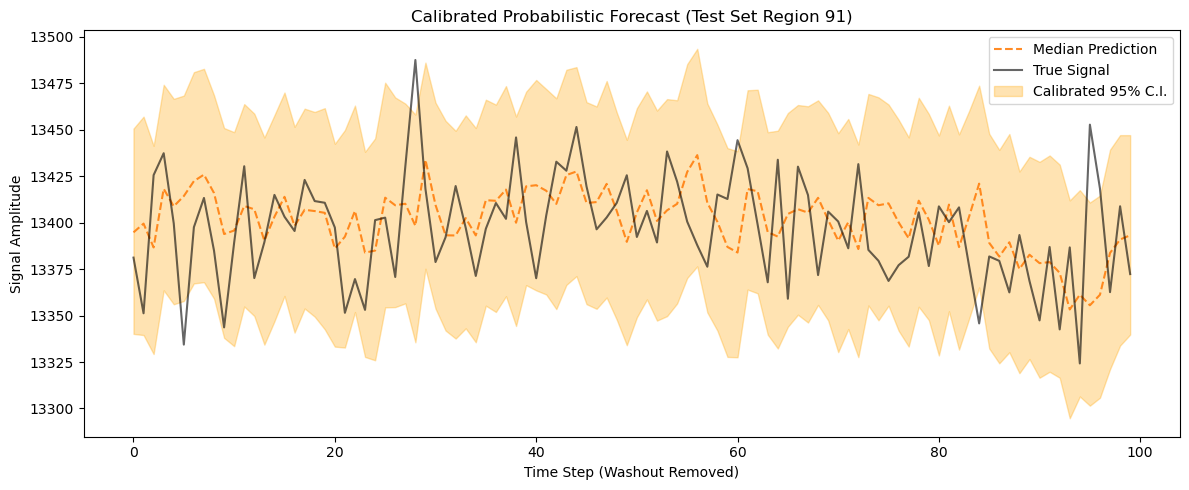

In [33]:
region_idx = np.random.choice(target_dim)
# Final Continuous Metric Evaluation on the Calibrated Test Set
# To evaluate mCRPS/Width correctly, generate the test samples using the newly adjusted quantiles
# Note: For scale-dependent metrics, apply  inverse z-score transformation here

y_pred_test_rescaled = z_rescale_tensor(torch.tensor(y_pred_test_z), train_mean, train_std)
Y_test_rescaled = z_rescale_tensor(torch.tensor(Y_test_stack), train_mean, train_std)

# Extract region-specific adjusted probability masses from the Isotonic matrix
q_lower_adj = adj_quantiles[0, region_idx]
q_upper_adj = adj_quantiles[-1, region_idx]

# Isolate region tensors
y_pred_test_reg = y_pred_test_rescaled[:, :, region_idx]
Y_test_reg = Y_test_rescaled[:, region_idx].numpy()

hor = block_size

# Extract calibrated bounds utilizing the adjusted quantiles
median_prediction_cal = torch.quantile(y_pred_test_reg, 0.5, dim=0).numpy()
lower_bound_cal = torch.quantile(y_pred_test_reg, q_lower_adj, dim=0).numpy()
upper_bound_cal = torch.quantile(y_pred_test_reg, q_upper_adj, dim=0).numpy()

plt.figure(figsize=(12, 5))
plt.plot(median_prediction_cal[:hor], "C1--", alpha=0.9, label="Median Prediction")
plt.plot(Y_test_reg[:hor], "k-", alpha=0.6, label="True Signal")
plt.fill_between(
    range(hor),
    lower_bound_cal[:hor],
    upper_bound_cal[:hor],
    color="orange",
    alpha=0.3,
    label="Calibrated 95% C.I."
)

plt.xlabel("Time Step (Washout Removed)")
plt.ylabel("Signal Amplitude")
plt.title(f"Calibrated Probabilistic Forecast (Test Set Region {region_idx})")
plt.tight_layout()
plt.legend()
plt.show()

In [34]:
# Recalibrated Quantile Extraction for metrics
cov_test, cal_error, mcrps_test, width_test = evaluate_metrics(
    y_pred_test_rescaled, 
    Y_test_rescaled, 
    cov_prob=0.95, 
    quantiles=adj_quantiles # Note: to evaluate on recalibrated quantiles
)

print(f"Calibrate Empirical Coverage: {cov_test.mean():.4%} (Target: 95%)")
print(f"Calibrate Calibration Error: {cal_error.mean():.4%} (Target: 0%)")
print(f"Calibrated Test mCRPS: {mcrps_test.mean().item():.4f}")
print(f"Calibrated Test Width: {width_test.mean().item():.4f}")

Calibrate Empirical Coverage: 93.6103% (Target: 95%)
Calibrate Calibration Error: 2.2805% (Target: 0%)
Calibrated Test mCRPS: 23.1597
Calibrated Test Width: 270.8411
